In [5]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"C:\Users\shita\Downloads\ddeep learning project\archive (6)\Road.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [8]:
df.shape
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

Index(['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Number_of_vehicles_involved',
       'Number_of_casualties', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident', 'Accident_severity'],
      dtype='str')

In [9]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Accident_severity'].value_counts()

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

In [12]:
df['Accident_severity'].value_counts(normalize=True) * 100

Accident_severity
Slight Injury     84.564794
Serious Injury    14.152322
Fatal injury       1.282884
Name: proportion, dtype: float64

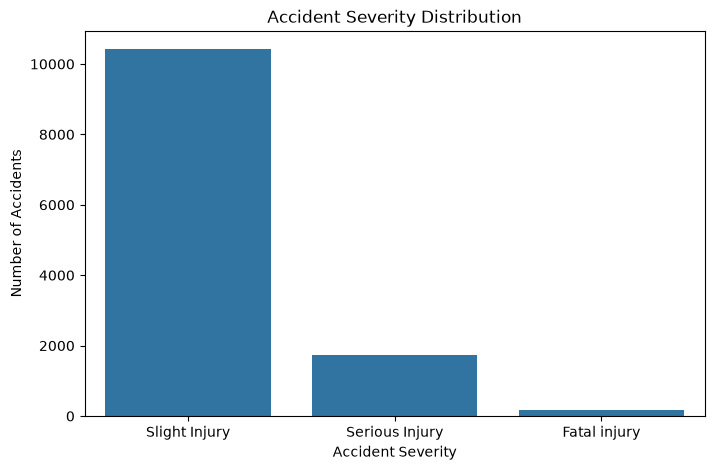

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(x='Accident_severity', data=df)

plt.title('Accident Severity Distribution')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')

plt.show()

In [14]:
df[['Number_of_vehicles_involved', 'Number_of_casualties']].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


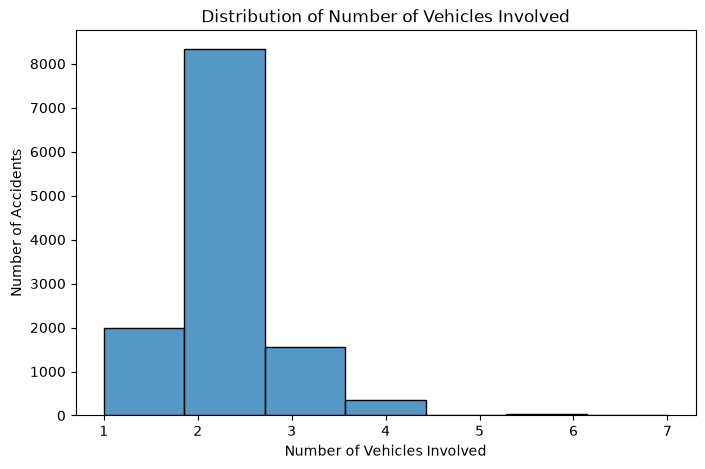

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Number_of_vehicles_involved'], bins=7, kde=False)

plt.title('Distribution of Number of Vehicles Involved')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Accidents')

plt.show()

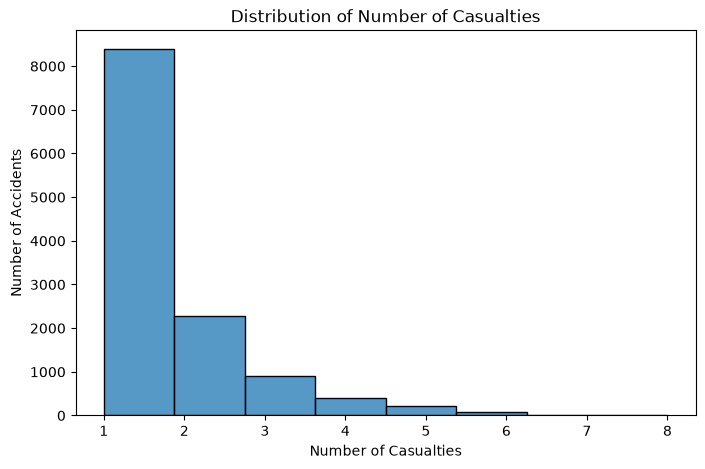

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Number_of_casualties'], bins=8, kde=False)

plt.title('Distribution of Number of Casualties')
plt.xlabel('Number of Casualties')
plt.ylabel('Number of Accidents')

plt.show()

In [17]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Time: 1074 unique values
Day_of_week: 7 unique values
Age_band_of_driver: 5 unique values
Sex_of_driver: 3 unique values
Educational_level: 7 unique values
Vehicle_driver_relation: 4 unique values
Driving_experience: 7 unique values
Type_of_vehicle: 17 unique values
Owner_of_vehicle: 4 unique values
Service_year_of_vehicle: 6 unique values
Defect_of_vehicle: 3 unique values
Area_accident_occured: 14 unique values
Lanes_or_Medians: 7 unique values
Road_allignment: 9 unique values
Types_of_Junction: 8 unique values
Road_surface_type: 5 unique values
Road_surface_conditions: 4 unique values
Light_conditions: 4 unique values
Weather_conditions: 9 unique values
Type_of_collision: 10 unique values
Vehicle_movement: 13 unique values
Casualty_class: 4 unique values
Sex_of_casualty: 3 unique values
Age_band_of_casualty: 6 unique values
Casualty_severity: 4 unique values
Work_of_casuality: 7 unique values
Fitness_of_casuality: 5 unique values
Pedestrian_movement: 9 unique values
Cause_of_acciden

C:\Users\shita\AppData\Local\Temp\ipykernel_14460\1263483761.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


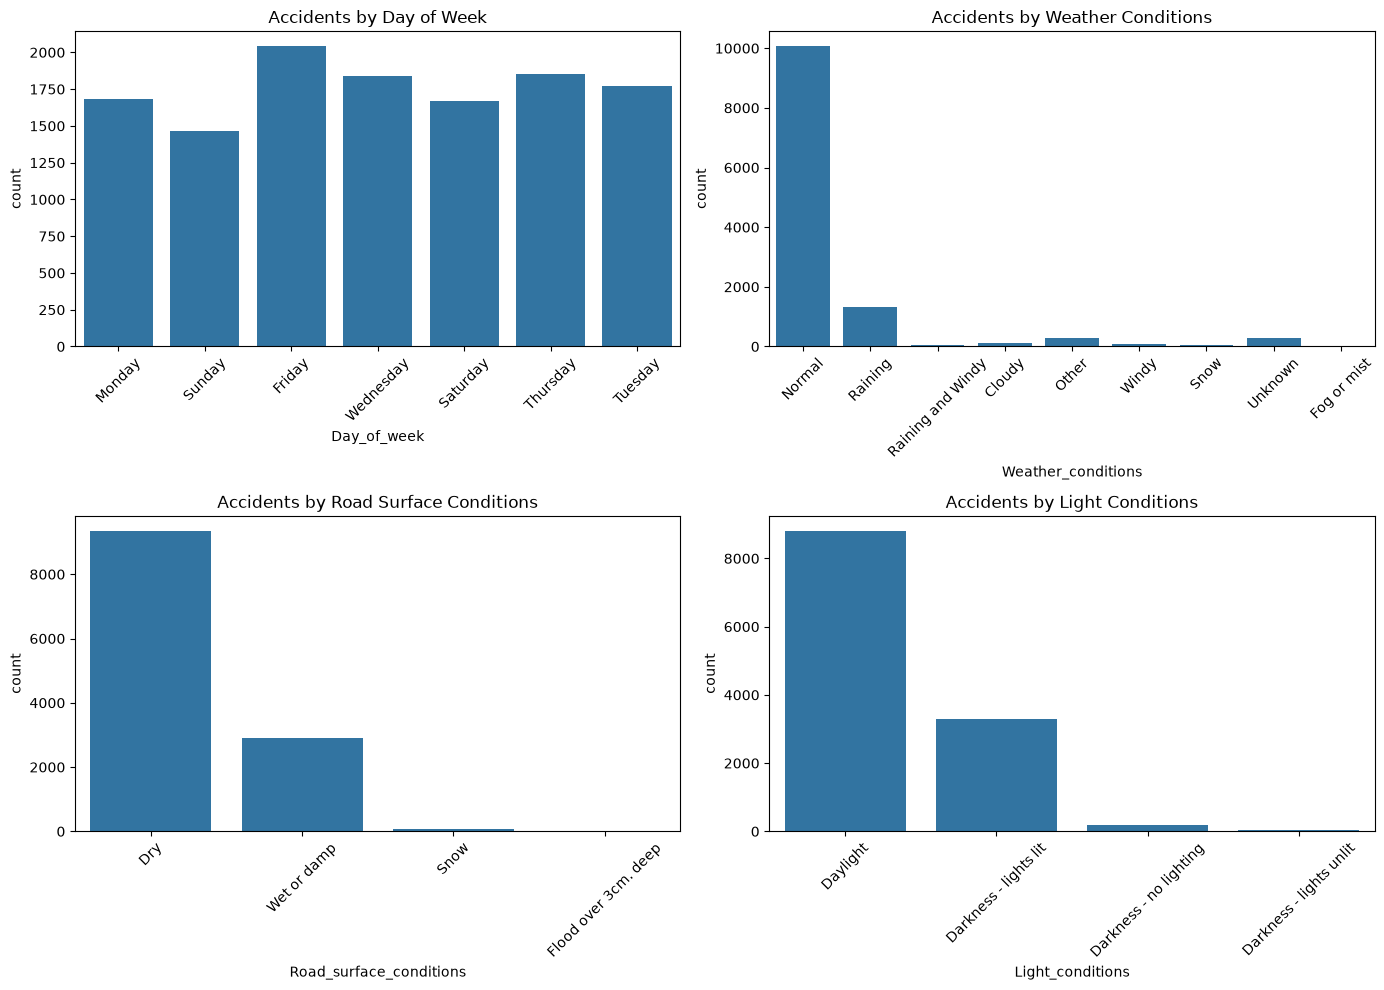

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(data=df, x='Day_of_week', ax=axes[0,0])
axes[0,0].set_title('Accidents by Day of Week')
axes[0,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Weather_conditions', ax=axes[0,1])
axes[0,1].set_title('Accidents by Weather Conditions')
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Road_surface_conditions', ax=axes[1,0])
axes[1,0].set_title('Accidents by Road Surface Conditions')
axes[1,0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Light_conditions', ax=axes[1,1])
axes[1,1].set_title('Accidents by Light Conditions')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

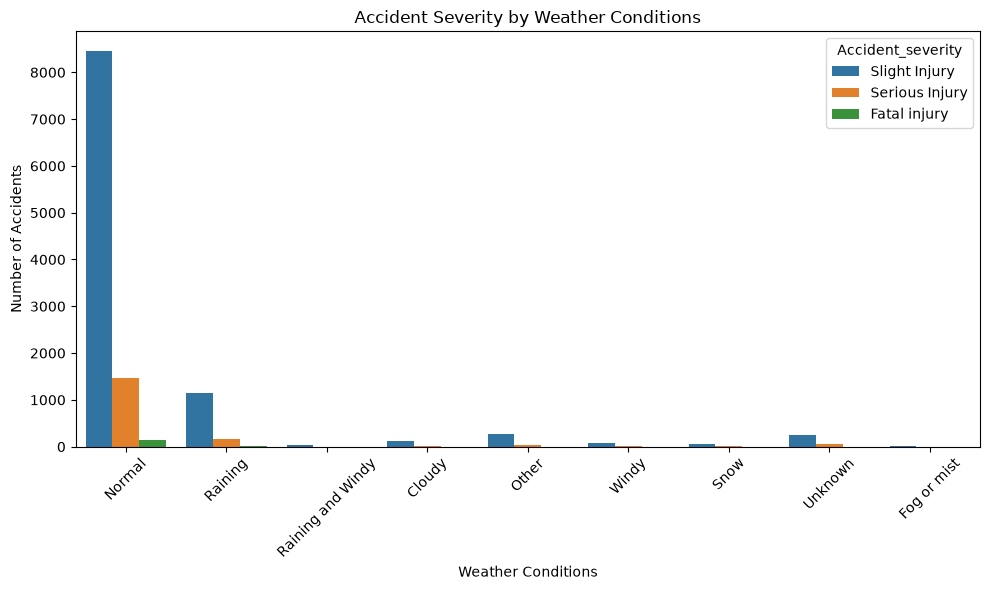

In [19]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='Weather_conditions', hue='Accident_severity')

plt.title('Accident Severity by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

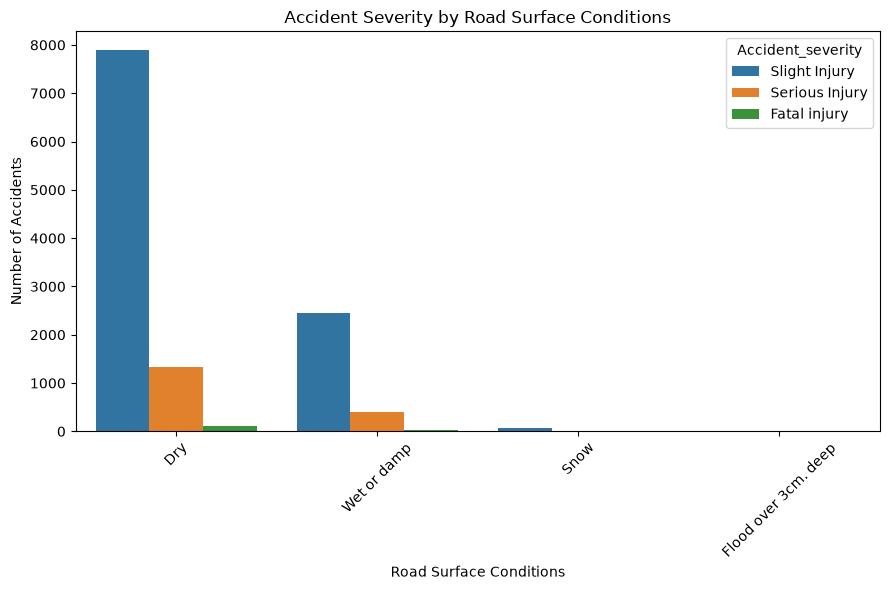

In [20]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, x='Road_surface_conditions', hue='Accident_severity')

plt.title('Accident Severity by Road Surface Conditions')
plt.xlabel('Road Surface Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

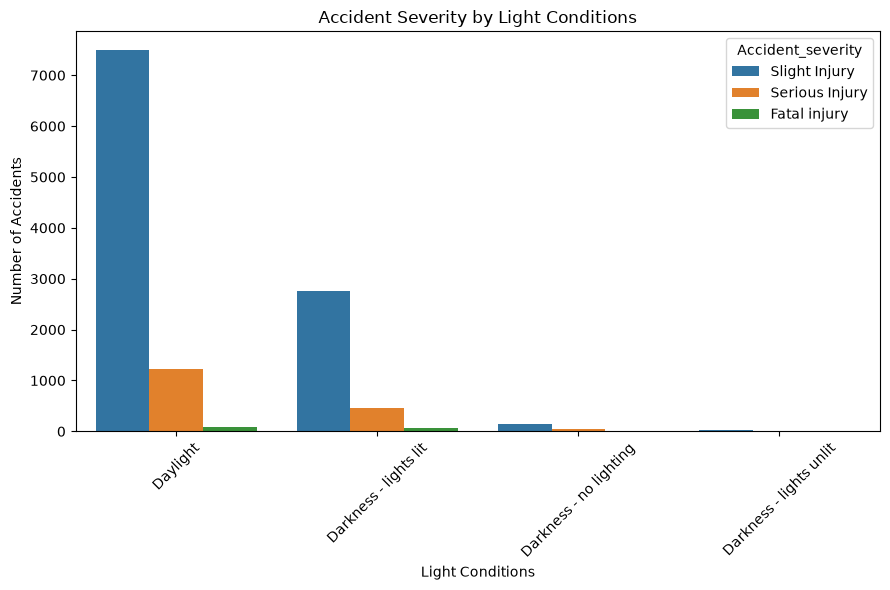

In [21]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, x='Light_conditions', hue='Accident_severity')

plt.title('Accident Severity by Light Conditions')
plt.xlabel('Light Conditions')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

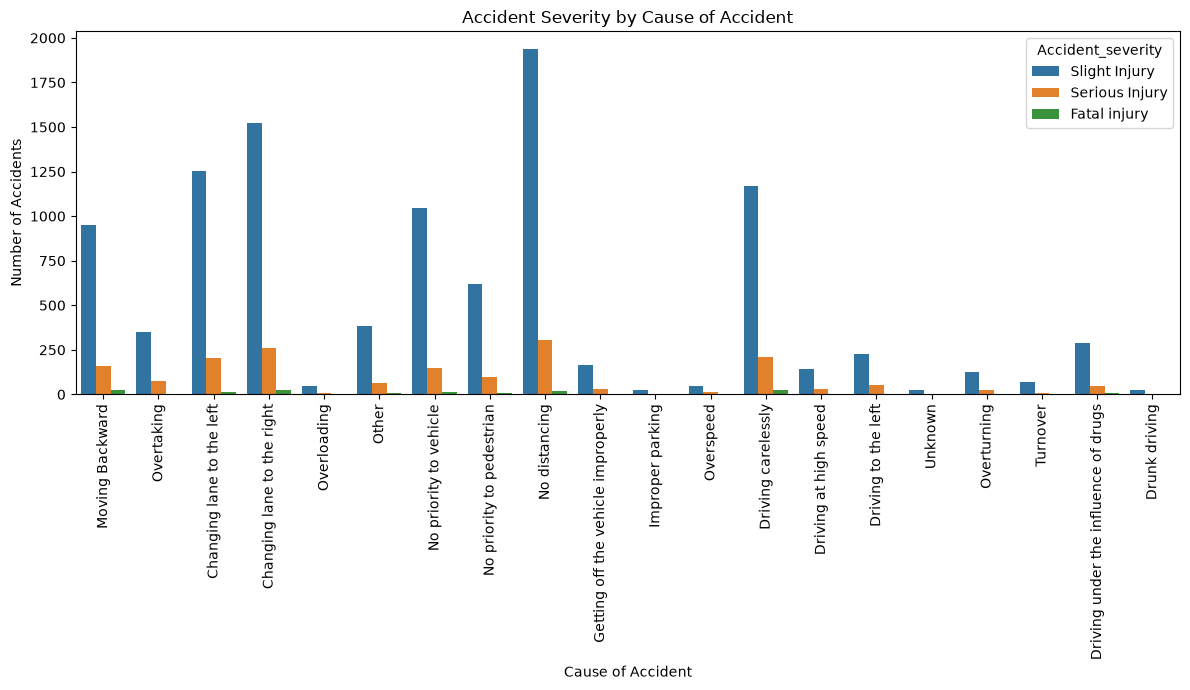

In [22]:
plt.figure(figsize=(12,7))

sns.countplot(data=df, x='Cause_of_accident', hue='Accident_severity')

plt.title('Accident Severity by Cause of Accident')
plt.xlabel('Cause of Accident')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [23]:
data = df.copy()

In [24]:
data['Hour'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.hour

In [25]:
data.drop('Time', axis=1, inplace=True)

In [26]:
data.fillna('Unknown', inplace=True)

,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Driver or rider,Male,31-50,3,Driver,Unknown,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,na,na,na,na,Unknown,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,Wednesday,31-50,Male,Unknown,Employee,2-5yr,Lorry (11?40Q),Owner,Unknown,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury,16
12312,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,Unknown,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury,18
12313,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,No defect,...,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury,13
12314,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,No defect,...,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury,13


In [27]:
data.isnull().sum().sum()

np.int64(0)

In [28]:
X = data.drop('Accident_severity', axis=1)
y = data['Accident_severity']

In [29]:
X.shape, y.shape

((12316, 31), (12316,))

In [30]:
categorical_columns = X.select_dtypes(include=['object', 'str']).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index(['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver',
       'Educational_level', 'Vehicle_driver_relation', 'Driving_experience',
       'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle',
       'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians',
       'Road_allignment', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Type_of_collision', 'Vehicle_movement', 'Casualty_class',
       'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity',
       'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement',
       'Cause_of_accident'],
      dtype='str')


In [31]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

X_encoded.head()

,Number_of_vehicles_involved,Number_of_casualties,Hour,Day_of_week_Monday,Day_of_week_Saturday,Day_of_week_Sunday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Age_band_of_driver_31-50,...,Cause_of_accident_No distancing,Cause_of_accident_No priority to pedestrian,Cause_of_accident_No priority to vehicle,Cause_of_accident_Other,Cause_of_accident_Overloading,Cause_of_accident_Overspeed,Cause_of_accident_Overtaking,Cause_of_accident_Overturning,Cause_of_accident_Turnover,Cause_of_accident_Unknown
0,2,2,17,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,2,17,1,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2,2,2,17,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,2,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)
print(y_encoded[:10])

['Fatal injury' 'Serious Injury' 'Slight Injury']
[2 2 1 2 2 2 2 2 2 1]


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9852, 186)
X_test shape: (2464, 186)
y_train shape: (9852,)
y_test shape: (2464,)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (9852, 186)
X_test_scaled shape: (2464, 186)


In [35]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


In [36]:
from sklearn.metrics import accuracy_score, classification_report

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.8453733766233766

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.67      0.01      0.01       349
           2       0.85      1.00      0.92      2084

    accuracy                           0.85      2464
   macro avg       0.50      0.33      0.31      2464
weighted avg       0.81      0.85      0.78      2464



In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.84375

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.42      0.05      0.10       349
           2       0.85      0.99      0.91      2084

    accuracy                           0.84      2464
   macro avg       0.42      0.35      0.34      2464
weighted avg       0.78      0.84      0.79      2464



C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [38]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6789772727272727

Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.06      0.08        31
           1       0.18      0.33      0.24       349
           2       0.86      0.75      0.80      2084

    accuracy                           0.68      2464
   macro avg       0.38      0.38      0.37      2464
weighted avg       0.75      0.68      0.71      2464



In [39]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [40]:
model = keras.Sequential([
    keras.layers.Input(shape=(186,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

model.summary()





Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │          23,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,371 (134.26 KB)

 Trainable params: 34,371 (134.26 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# ADDITIONAL - Keep DNN model separately

dnn_model = model

In [42]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [44]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8325 - loss: 0.5131 - val_accuracy: 0.8422 - val_loss: 0.4799
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8466 - loss: 0.4383 - val_accuracy: 0.8422 - val_loss: 0.4845
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8477 - loss: 0.3988 - val_accuracy: 0.8417 - val_loss: 0.4995
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8604 - loss: 0.3524 - val_accuracy: 0.8341 - val_loss: 0.5284
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8822 - loss: 0.2905 - val_accuracy: 0.7945 - val_loss: 0.5874
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9098 - loss: 0.2317 - val_accuracy: 0.8143 - val_loss: 0.6594


In [45]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("DNN Test Accuracy:", test_accuracy)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8458 - loss: 0.4804
DNN Test Accuracy: 0.8457792401313782


In [46]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = np.argmax(y_pred_prob, axis=1)

print("Predicted classes:", y_pred[:10])

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted classes: [2 2 2 2 2 2 2 2 2 2]


In [47]:
from sklearn.metrics import classification_report

print("DNN Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_.astype(str)
    )
)

DNN Classification Report:
                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       0.00      0.00      0.00       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.28      0.33      0.31      2464
  weighted avg       0.72      0.85      0.78      2464



C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

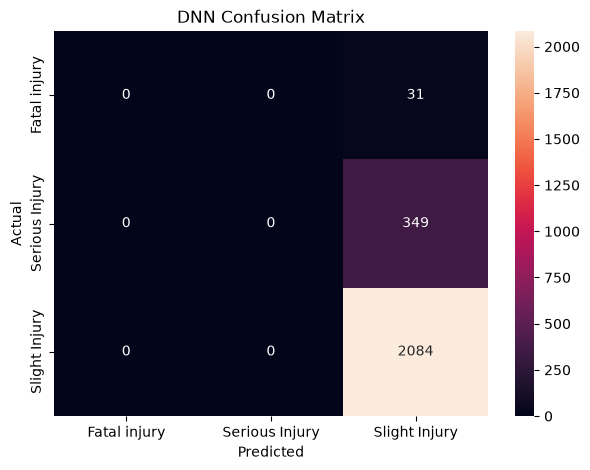

In [48]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DNN Confusion Matrix")

plt.show()

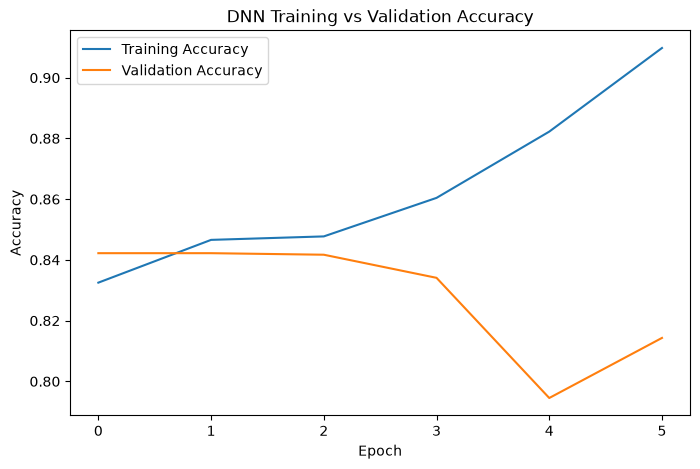

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DNN Training vs Validation Accuracy")
plt.legend()
plt.show()

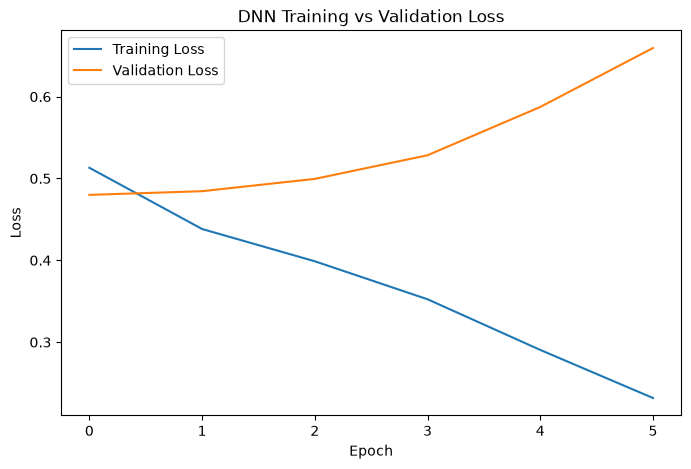

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DNN Training vs Validation Loss")
plt.legend()
plt.show()

In [51]:
import os

dataset_path = r"C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022"

print("Dataset exists:", os.path.exists(dataset_path))

print("\nDataset Structure:")
print("data.yaml:", os.path.exists(os.path.join(dataset_path, "data.yaml")))
print("train/images:", os.path.exists(os.path.join(dataset_path, "train", "images")))
print("train/labels:", os.path.exists(os.path.join(dataset_path, "train", "labels")))
print("valid/images:", os.path.exists(os.path.join(dataset_path, "valid", "images")))
print("valid/labels:", os.path.exists(os.path.join(dataset_path, "valid", "labels")))
print("test/images:", os.path.exists(os.path.join(dataset_path, "test", "images")))
print("test/labels:", os.path.exists(os.path.join(dataset_path, "test", "labels")))

Dataset exists: True

Dataset Structure:
data.yaml: True
train/images: True
train/labels: True
valid/images: True
valid/labels: True
test/images: True
test/labels: True


In [52]:
import os

# Count images and labels
train_images = len(os.listdir(os.path.join(dataset_path, "train", "images")))
train_labels = len(os.listdir(os.path.join(dataset_path, "train", "labels")))

valid_images = len(os.listdir(os.path.join(dataset_path, "valid", "images")))
valid_labels = len(os.listdir(os.path.join(dataset_path, "valid", "labels")))

test_images = len(os.listdir(os.path.join(dataset_path, "test", "images")))
test_labels = len(os.listdir(os.path.join(dataset_path, "test", "labels")))

print("Dataset Counts")
print("=" * 40)

print(f"Train Images : {train_images}")
print(f"Train Labels : {train_labels}")

print(f"\nValidation Images : {valid_images}")
print(f"Validation Labels : {valid_labels}")

print(f"\nTest Images : {test_images}")
print(f"Test Labels : {test_labels}")

Dataset Counts
Train Images : 2781
Train Labels : 2781

Validation Images : 348
Validation Labels : 348

Test Images : 348
Test Labels : 348


In [53]:
# YOLO Label Class Verification

import os

label_folders = [
    os.path.join(dataset_path, "train", "labels"),
    os.path.join(dataset_path, "valid", "labels"),
    os.path.join(dataset_path, "test", "labels")
]

class_ids = set()
invalid_labels = []

for folder in label_folders:
    for file in os.listdir(folder):
        if file.endswith(".txt"):
            file_path = os.path.join(folder, file)

            with open(file_path, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        class_ids.add(class_id)

                        if class_id < 0 or class_id >= 22:
                            invalid_labels.append((file, class_id))

print("Classes found in labels:")
print(sorted(class_ids))

print("\nNumber of classes found:", len(class_ids))

if invalid_labels:
    print("\nInvalid class IDs found:")
    print(invalid_labels[:10])
else:
    print("\nNo invalid class IDs found. Dataset labels are valid.")

Classes found in labels:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

Number of classes found: 22

No invalid class IDs found. Dataset labels are valid.


In [54]:
%pip install ultralytics

Note: you may need to restart the kernel to use updated packages.


In [55]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully.")

YOLO model loaded successfully.


In [56]:
last_model = r"C:\Users\shita\runs\detect\runs\dats2022_yolo_fast\weights\last.pt"

print("Checkpoint exists:", os.path.exists(last_model))

Checkpoint exists: True


In [57]:
from ultralytics import YOLO

last_model = r"C:\Users\shita\runs\detect\runs\dats2022_yolo_fast\weights\last.pt"

model = YOLO(last_model)

results = model.train(
    resume=True
)

print("YOLO training resumed successfully.")

New https://pypi.org/project/ultralytics/8.4.138 available  Update with 'pip install -U ultralytics'
WARNING model 'C:\Users\shita\runs\detect\runs\dats2022_yolo_fast\weights\last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.131  Python-3.13.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, 

In [58]:
from ultralytics import YOLO

best_model_path = r"C:\Users\shita\runs\detect\runs\dats2022_yolo_fast\weights\best.pt"

best_model = YOLO(best_model_path)

print("Best YOLO model loaded successfully.")

Best YOLO model loaded successfully.


In [59]:
import os

dataset_path = r"C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022"
data_yaml = os.path.join(dataset_path, "data.yaml")

print("data.yaml exists:", os.path.exists(data_yaml))
print("data.yaml path:", data_yaml)

data.yaml exists: True
data.yaml path: C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\data.yaml


In [60]:
metrics = best_model.val(
    data=data_yaml,
    imgsz=416,
    batch=8,
    device="cpu"
)

print("YOLO validation completed.")

Ultralytics 8.4.131  Python-3.13.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12500H)
Model summary (fused): 73 layers, 3,009,938 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.30.0 ms, read: 27.712.5 MB/s, size: 45.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\valid\labels.cache... 348 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 348/348 60.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 1.4it/s 31.3s0.7ss
                   all        348       1797      0.579      0.453      0.469      0.259
                Animal         22         61      0.557      0.639      0.616      0.319
             Lamp Post         45         85      0.444      0.435      0.397      0.156
               R

In [61]:
# YOLO Test Prediction

test_path = os.path.join(dataset_path, "test", "images")

results = best_model.predict(
    source=test_path,
    imgsz=416,
    conf=0.25,
    device="cpu",
    save=True
)

print("YOLO test predictions completed.")


image 1/348 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\1634016299572_jpg.rf.7baea07d3c8049b2873f69babe8efa23.jpg: 416x416 4 Animals, 143.1ms
image 2/348 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\1634016299581_jpg.rf.507dcf169165f515a146928abfcb7843.jpg: 416x416 (no detections), 85.5ms
image 3/348 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\1634017592968_jpg.rf.d3ebf0860db553dfb61eabe01aca8aef.jpg: 416x416 2 Animals, 1 Board, 1 Car, 1 Electricity Pole, 77.8ms
image 4/348 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\1634017592994_jpg.rf.122117cca7d218268e708b80cd0a4ac9.jpg: 416x416 4 Animals, 1 person, 73.2ms
image 5/348 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\1634017593002_jpg.rf.39846ba2f84a68213887d1f3ad6fceee.jpg: 416x416 3 Animals, 2 Two-wheelers, 1 person, 74.8ms
image 6/348 C:\Users\shit

Test image path:
C:\Users\shita\runs\detect\predict-2\IMG_20211220_165924_jpg.rf.833f974151b8f179da5452864050b182.jpg


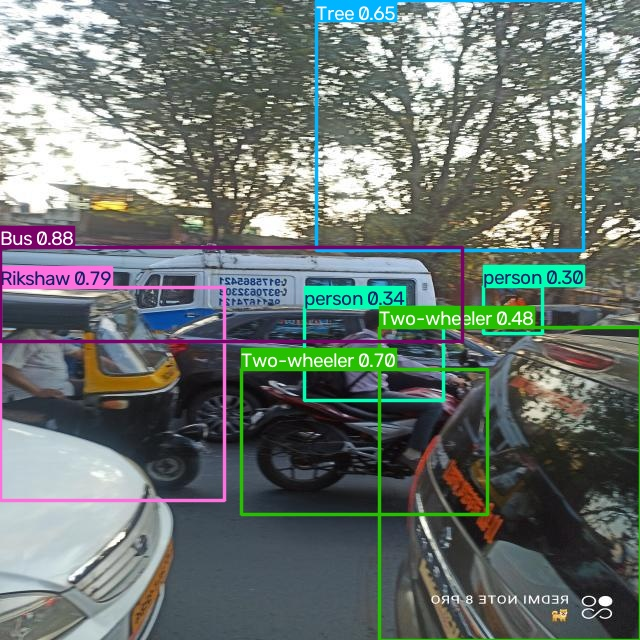

YOLO detected test image displayed successfully.


In [62]:


from IPython.display import display
from PIL import Image
import os

predict_folder = r"C:\Users\shita\runs\detect\predict-2"

test_image_name = "IMG_20211220_165924_jpg.rf.833f974151b8f179da5452864050b182.jpg"

result_image = os.path.join(predict_folder, test_image_name)

print("Test image path:")
print(result_image)

if os.path.exists(result_image):
    display(Image.open(result_image))
    print("YOLO detected test image displayed successfully.")
else:
    print("Test image not found in predict-2 folder.")

In [63]:
# YOLO Scene Object Detection

test_results = best_model.predict(
    source=result_image,
    imgsz=416,
    conf=0.25,
    device="cpu",
    verbose=False
)

class_names = best_model.names

object_counts = {}

for result in test_results:
    if result.boxes is not None:
        for cls in result.boxes.cls:
            class_id = int(cls)
            class_name = class_names[class_id]

            if class_name in object_counts:
                object_counts[class_name] += 1
            else:
                object_counts[class_name] = 1

print("Detected Objects:")
for name, count in object_counts.items():
    print(f"{name}: {count}")

Detected Objects:
Tree: 1
Bus: 2
Rikshaw: 1


In [64]:
# YOLO Scene Risk Features

scene_features = {
    "Cars": object_counts.get("Car", 0),
    "Two-wheelers": object_counts.get("Two-wheeler", 0),
    "Rikshaws": object_counts.get("Rikshaw", 0),
    "Trucks": object_counts.get("Truck", 0),
    "Buses": object_counts.get("Bus", 0),
    "Tempos": object_counts.get("Tempo", 0),
    "Persons": object_counts.get("person", 0),
    "Traffic Signals": object_counts.get("Traffic Signal", 0),
    "Road Dividers": object_counts.get("Road Divider", 0),
    "Animals": object_counts.get("Animal", 0)
}

print("YOLO Scene Features:")
print("================================")

for feature, value in scene_features.items():
    print(f"{feature}: {value}")

YOLO Scene Features:
Cars: 0
Two-wheelers: 0
Rikshaws: 1
Trucks: 0
Buses: 2
Tempos: 0
Persons: 0
Traffic Signals: 0
Road Dividers: 0
Animals: 0


In [65]:
# DNN Prediction for Risk Fusion

dnn_predictions = dnn_model.predict(X_test_scaled)

print("DNN predictions generated successfully.")
print("Prediction shape:", dnn_predictions.shape)

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
DNN predictions generated successfully.
Prediction shape: (2464, 3)


In [66]:
# DNN Predicted Classes

dnn_predicted_classes = dnn_predictions.argmax(axis=1)

print("DNN predicted classes generated successfully.")
print("Number of predictions:", len(dnn_predicted_classes))
print("Unique predicted classes:", set(dnn_predicted_classes))

DNN predicted classes generated successfully.
Number of predictions: 2464
Unique predicted classes: {np.int64(2)}


In [67]:
# Risk Fusion: DNN + YOLO Scene Features

dnn_risk_score = dnn_predictions.max(axis=1)

yolo_risk_score = (
    scene_features["Cars"]
    + scene_features["Two-wheelers"]
    + scene_features["Rikshaws"]
    + scene_features["Trucks"]
    + scene_features["Buses"]
    + scene_features["Tempos"]
    + scene_features["Persons"]
    + scene_features["Traffic Signals"]
    + scene_features["Road Dividers"]
    + scene_features["Animals"]
)

print("Risk fusion completed.")
print("DNN risk score generated.")
print("YOLO scene risk score:", yolo_risk_score)

Risk fusion completed.
DNN risk score generated.
YOLO scene risk score: 3


In [68]:
# YOLO Test on a Road Image

test_image = r"C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\IMG_20211220_165924_jpg.rf.833f974151b8f179da5452864050b182.jpg"

test_results = best_model.predict(
    source=test_image,
    imgsz=416,
    conf=0.25,
    save=True
)

print("YOLO testing completed.")
print("Test image:", test_image)


image 1/1 C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\IMG_20211220_165924_jpg.rf.833f974151b8f179da5452864050b182.jpg: 416x416 1 Rikshaw, 1 Tree, 2 Two-wheelers, 2 persons, 1 Bus, 104.3ms
Speed: 3.2ms preprocess, 104.3ms inference, 2.6ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\shita\runs\detect\predict-11
YOLO testing completed.
Test image: C:\Users\shita\Downloads\ddeep learning project\archive (5)\DATS_2022\test\images\IMG_20211220_165924_jpg.rf.833f974151b8f179da5452864050b182.jpg


In [69]:
# YOLO Scene Features from Test Image

test_object_counts = {}

for result in test_results:
    if result.boxes is not None:
        for cls in result.boxes.cls:
            class_id = int(cls)
            class_name = best_model.names[class_id]

            if class_name in test_object_counts:
                test_object_counts[class_name] += 1
            else:
                test_object_counts[class_name] = 1

print("Test Image Scene Features:")
print("================================")

for name, count in test_object_counts.items():
    print(f"{name}: {count}")

Test Image Scene Features:
Bus: 1
Rikshaw: 1
Two-wheeler: 2
Tree: 1
person: 2


In [70]:
# YOLO Risk Score for Test Image

test_yolo_risk_score = (
    test_object_counts.get("Bus", 0)
    + test_object_counts.get("Rikshaw", 0)
    + test_object_counts.get("Two-wheeler", 0)
    + test_object_counts.get("Truck", 0)
    + test_object_counts.get("Car", 0)
    + test_object_counts.get("Tempo", 0)
    + test_object_counts.get("person", 0)
)

print("Test Image YOLO Risk Score")
print("==========================")
print("YOLO Risk Score:", test_yolo_risk_score)

Test Image YOLO Risk Score
YOLO Risk Score: 6


In [90]:
# Step 12 - YOLO Test Prediction Summary

from ultralytics import YOLO

best_model_path = r"C:\Users\shita\runs\detect\runs\dats2022_yolo_fast\weights\best.pt"

best_model = YOLO(best_model_path)

test_results = best_model.predict(
    source=result_image,
    imgsz=416,
    conf=0.25,
    device="cpu",
    verbose=False
)

test_object_counts = {}

for result in test_results:
    if result.boxes is not None:
        for cls in result.boxes.cls:
            class_id = int(cls)
            class_name = best_model.names[class_id]

            if class_name in test_object_counts:
                test_object_counts[class_name] += 1
            else:
                test_object_counts[class_name] = 1

print("YOLO Test Prediction Summary")
print("============================")

for name, count in test_object_counts.items():
    print(f"{name}: {count}")

print("\nTotal detected objects:", sum(test_object_counts.values()))

YOLO Test Prediction Summary
Tree: 1
Bus: 2
Rikshaw: 1

Total detected objects: 4


In [91]:
# Step 13 - Test Image YOLO Risk Score

total_detected_objects = sum(test_object_counts.values())

# Normalize YOLO risk score
test_yolo_normalized = min(total_detected_objects / 10, 1.0)

print("Test Image YOLO Risk Score")
print("==========================")
print("Detected objects:", total_detected_objects)
print("Normalized YOLO Risk Score:", round(test_yolo_normalized, 3))

Test Image YOLO Risk Score
Detected objects: 4
Normalized YOLO Risk Score: 0.4


In [92]:
# Step 14 - Final Risk Fusion for Test Image

dnn_test_risk_score = dnn_predictions.max(axis=1).mean()

final_test_risk_score = (
    0.6 * dnn_test_risk_score
    + 0.4 * test_yolo_normalized
)

if final_test_risk_score < 0.40:
    final_test_risk_level = "Low"

elif final_test_risk_score < 0.70:
    final_test_risk_level = "Medium"

else:
    final_test_risk_level = "High"

print("Final Risk Assessment")
print("=====================")
print("DNN Risk Score:", round(dnn_test_risk_score, 4))
print("YOLO Normalized Risk Score:", round(test_yolo_normalized, 3))
print("Final Risk Score:", round(final_test_risk_score, 4))
print("Final Risk Level:", final_test_risk_level)

Final Risk Assessment
DNN Risk Score: 0.8495
YOLO Normalized Risk Score: 0.4
Final Risk Score: 0.6697
Final Risk Level: Medium


In [93]:
# Step 15 - Prevention Advice for Test Image

if final_test_risk_level == "Low":
    test_prevention_advice = [
        "Maintain safe driving speed.",
        "Continue following traffic rules.",
        "Stay alert and maintain a safe distance."
    ]

elif final_test_risk_level == "Medium":
    test_prevention_advice = [
        "Reduce vehicle speed and drive cautiously.",
        "Maintain a safe distance from other vehicles.",
        "Be alert around pedestrians and two-wheelers.",
        "Follow traffic signals and road safety rules."
    ]

else:
    test_prevention_advice = [
        "Immediately reduce vehicle speed.",
        "Maintain a large safety distance from other vehicles.",
        "Avoid sudden braking and risky overtaking.",
        "Be highly alert around pedestrians and two-wheelers.",
        "Follow all traffic signals and road safety rules."
    ]

print("Accident Prevention Advice")
print("==========================")

for advice in test_prevention_advice:
    print("-", advice)

Accident Prevention Advice
- Reduce vehicle speed and drive cautiously.
- Maintain a safe distance from other vehicles.
- Be alert around pedestrians and two-wheelers.
- Follow traffic signals and road safety rules.


In [94]:
# Step 16 - Verify DNN Model Before SHAP

print("Checking DNN model before SHAP...")
print("DNN model type:", type(dnn_model))
print("Input shape:", dnn_model.input_shape)
print("Output shape:", dnn_model.output_shape)

Checking DNN model before SHAP...
DNN model type: <class 'keras.src.models.sequential.Sequential'>
Input shape: (None, 186)
Output shape: (None, 3)


In [95]:
# Step 17 - SHAP Library Check

import shap

print("SHAP library loaded successfully.")
print("SHAP version:", shap.__version__)

SHAP library loaded successfully.
SHAP version: 0.52.0


In [96]:
# Step 18 - Create SHAP Explainer for DNN

print("Creating SHAP explainer...")

background_data = X_train_scaled[:100]

explainer = shap.DeepExplainer(
    dnn_model,
    background_data
)

print("SHAP explainer created successfully.")

Creating SHAP explainer...
SHAP explainer created successfully.


C:\Users\shita\Downloads\anaconda\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 186))']
  warnings.warn(msg)


In [97]:
# Step 19 - Generate SHAP Values

print("Generating SHAP values...")

shap_sample = X_test_scaled[:100]

shap_values = explainer.shap_values(shap_sample)

print("SHAP values generated successfully.")
print("Number of SHAP outputs:", len(shap_values))

Generating SHAP values...


C:\Users\shita\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 186))']
  warnings.warn(msg)


SHAP values generated successfully.
Number of SHAP outputs: 100


In [98]:
# Step 20 - Correct SHAP Value Structure

import numpy as np

print("Checking corrected SHAP value structure...")

shap_array = np.asarray(shap_values)

print("Original SHAP array shape:", shap_array.shape)

# Convert SHAP output to:
# Samples × Features × Classes

if shap_array.ndim == 3:
    if shap_array.shape[0] == 100 and shap_array.shape[1] == 186:
        corrected_shap_values = shap_array
    elif shap_array.shape[0] == 186 and shap_array.shape[1] == 100:
        corrected_shap_values = np.transpose(shap_array, (1, 0, 2))
    else:
        corrected_shap_values = shap_array
else:
    corrected_shap_values = np.asarray(
        shap_values
    )

print("Corrected SHAP array shape:", corrected_shap_values.shape)
print("SHAP structure correction completed.")

Checking corrected SHAP value structure...
Original SHAP array shape: (100, 186, 3)
Corrected SHAP array shape: (100, 186, 3)
SHAP structure correction completed.


In [99]:
# Step 21 - SHAP Feature Importance

import numpy as np

print("Calculating SHAP feature importance...")

# Average absolute SHAP value across samples and classes
shap_feature_importance = np.mean(
    np.abs(corrected_shap_values),
    axis=(0, 2)
)

print("SHAP feature importance calculated successfully.")
print("Number of features:", len(shap_feature_importance))

# Get feature names
feature_names = X_train.columns

# Create feature importance table
shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": shap_feature_importance
})

# Sort by importance
shap_importance_df = shap_importance_df.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("\nTop 10 Important Features:")
print(shap_importance_df.head(10))

Calculating SHAP feature importance...
SHAP feature importance calculated successfully.
Number of features: 186

Top 10 Important Features:
                                            Feature  Mean_Absolute_SHAP
0                       Number_of_vehicles_involved            0.016051
1                         Light_conditions_Daylight            0.013504
2           Cause_of_accident_Driving at high speed            0.012174
3               Educational_level_Writing & reading            0.012141
4                        Age_band_of_casualty_31-50            0.012019
5              Weather_conditions_Raining and Windy            0.011647
6  Type_of_collision_Vehicle with vehicle collision            0.011553
7                       Area_accident_occured_Other            0.011268
8                              Number_of_casualties            0.009140
9                          Driving_experience_2-5yr            0.008856


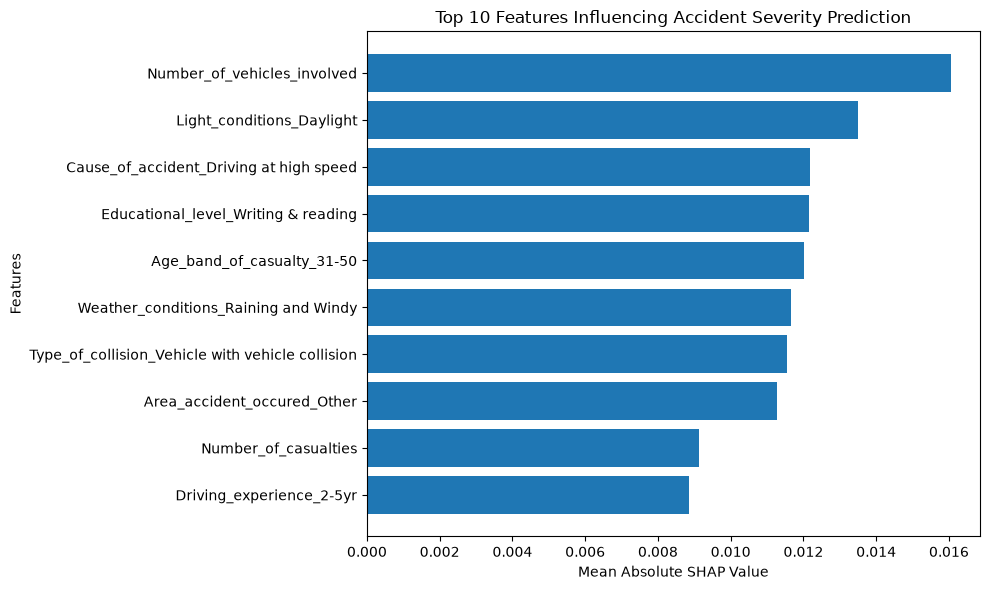

SHAP feature importance plot generated successfully.


In [100]:
# Step 22 - SHAP Feature Importance Plot

import matplotlib.pyplot as plt

top_features = shap_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing Accident Severity Prediction")

plt.tight_layout()
plt.show()

print("SHAP feature importance plot generated successfully.")

Generating SHAP summary plot...


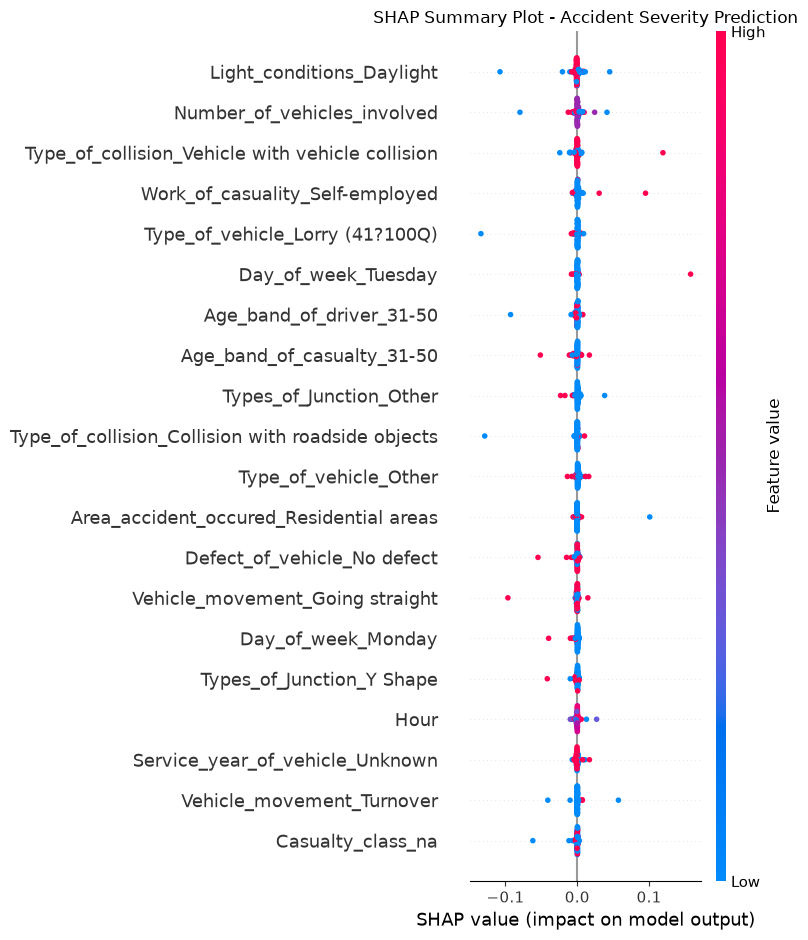

SHAP summary plot generated successfully.


In [101]:
# Step 23 - SHAP Summary Plot

import shap
import matplotlib.pyplot as plt

print("Generating SHAP summary plot...")

# Select Class 0 SHAP values
class_0_shap = corrected_shap_values[:, :, 0]

shap.summary_plot(
    class_0_shap,
    X_test.iloc[:100],
    feature_names=X_test.columns,
    show=False
)

plt.title("SHAP Summary Plot - Accident Severity Prediction")
plt.tight_layout()
plt.show()

print("SHAP summary plot generated successfully.")

In [102]:
# Step 24 - Top SHAP Features Report

top_10_shap_features = shap_importance_df.head(10).copy()

print("Top SHAP Features")
print("=================")

for index, row in top_10_shap_features.iterrows():
    print(
        f"{index + 1}. {row['Feature']} "
        f"-> SHAP Importance: {row['Mean_Absolute_SHAP']:.4f}"
    )

print("\nSHAP feature interpretation report generated successfully.")

Top SHAP Features
1. Number_of_vehicles_involved -> SHAP Importance: 0.0161
2. Light_conditions_Daylight -> SHAP Importance: 0.0135
3. Cause_of_accident_Driving at high speed -> SHAP Importance: 0.0122
4. Educational_level_Writing & reading -> SHAP Importance: 0.0121
5. Age_band_of_casualty_31-50 -> SHAP Importance: 0.0120
6. Weather_conditions_Raining and Windy -> SHAP Importance: 0.0116
7. Type_of_collision_Vehicle with vehicle collision -> SHAP Importance: 0.0116
8. Area_accident_occured_Other -> SHAP Importance: 0.0113
9. Number_of_casualties -> SHAP Importance: 0.0091
10. Driving_experience_2-5yr -> SHAP Importance: 0.0089

SHAP feature interpretation report generated successfully.


In [103]:
# Step 25 - Save SHAP Feature Importance

shap_output_path = r"C:\Users\shita\Downloads\ddeep learning project\SHAP_feature_importance.csv"

shap_importance_df.to_csv(
    shap_output_path,
    index=False
)

print("SHAP feature importance saved successfully.")
print("Saved file:")
print(shap_output_path)

SHAP feature importance saved successfully.
Saved file:
C:\Users\shita\Downloads\ddeep learning project\SHAP_feature_importance.csv


In [104]:
# Step 26 - Complete Project Final Validation

print("FINAL PROJECT VALIDATION")
print("========================")

print("\nDNN Model:")
print("Input shape:", dnn_model.input_shape)
print("Output shape:", dnn_model.output_shape)

print("\nYOLO Model:")
print("Model loaded:", best_model is not None)

print("\nYOLO Test Image:")
print("Detected objects:", sum(test_object_counts.values()))

print("\nRisk Fusion:")
print("DNN Risk Score:", round(dnn_test_risk_score, 4))
print("YOLO Risk Score:", round(test_yolo_normalized, 4))
print("Final Risk Score:", round(final_test_risk_score, 4))
print("Final Risk Level:", final_test_risk_level)

print("\nSHAP:")
print("Number of features analyzed:", len(shap_importance_df))
print("Top SHAP Feature:", shap_importance_df.iloc[0]["Feature"])

print("\nProject validation completed successfully.")

FINAL PROJECT VALIDATION

DNN Model:
Input shape: (None, 186)
Output shape: (None, 3)

YOLO Model:
Model loaded: True

YOLO Test Image:
Detected objects: 4

Risk Fusion:
DNN Risk Score: 0.8495
YOLO Risk Score: 0.4
Final Risk Score: 0.6697
Final Risk Level: Medium

SHAP:
Number of features analyzed: 186
Top SHAP Feature: Number_of_vehicles_involved

Project validation completed successfully.


In [105]:
# Step 27 - Final Project Results Summary

final_project_results = {
    "DNN_Input_Features": dnn_model.input_shape[1],
    "DNN_Output_Classes": dnn_model.output_shape[1],
    "YOLO_Detected_Objects": sum(test_object_counts.values()),
    "DNN_Risk_Score": round(dnn_test_risk_score, 4),
    "YOLO_Risk_Score": round(test_yolo_normalized, 4),
    "Final_Risk_Score": round(final_test_risk_score, 4),
    "Final_Risk_Level": final_test_risk_level,
    "SHAP_Features_Analyzed": len(shap_importance_df),
    "Top_SHAP_Feature": shap_importance_df.iloc[0]["Feature"]
}

print("FINAL PROJECT RESULTS")
print("=====================")

for key, value in final_project_results.items():
    print(f"{key}: {value}")

print("\nFinal project results summary generated successfully.")

FINAL PROJECT RESULTS
DNN_Input_Features: 186
DNN_Output_Classes: 3
YOLO_Detected_Objects: 4
DNN_Risk_Score: 0.8495000004768372
YOLO_Risk_Score: 0.4
Final_Risk_Score: 0.669700026512146
Final_Risk_Level: Medium
SHAP_Features_Analyzed: 186
Top_SHAP_Feature: Number_of_vehicles_involved

Final project results summary generated successfully.


In [109]:
import joblib

dnn_model.save("accident_risk_dnn.keras")
joblib.dump(scaler, "scaler.pkl")

print("Accident DNN model saved successfully.")

Accident DNN model saved successfully.
